# Enriched fragment combinations

Pairs of fragments that are **bonded to each other** in a compound, scored by how
much more often binders carry them. Then the same pairs clustered so that
variants differing only by a decoration (a fluorine, a methyl) are pooled.

**Two enrichment numbers, and why they differ**

| column | definition |
|---|---|
| `binder_per_nonbinder` | the raw ratio `n_binder / n_nonbinder` |
| `enrichment_factor` | **pooled**: that ratio divided by the library's own binder:non-binder ratio. Compares against the whole library at once |
| `enrichment_mh` | **stratified (Mantel–Haenszel)**: compares compounds only against others *from the same input shard*, then pools those per-shard comparisons. An odds ratio, but with binders this rare it reads on the same scale as the pooled factor |
| `enrichment_mh_lo95` | 95% lower bound on the stratified estimate — **the sort key** |
| `q_value_mh` | Benjamini–Hochberg FDR on the Mantel–Haenszel test |
| `n_strata` | **how many input shards the combination appears in at all.** Each input parquet is one stratum; a combination confined to one shard is scored only against that shard's own compounds |

Shards differ enormously in how many binders they contain, so the pooled factor
partly measures *which shard a compound came from*. That is what the stratified
estimate removes, and the two can differ by orders of magnitude — the scatter
below shows by how much on your data.

Rank on `enrichment_mh_lo95`. Never rank on a point estimate: combinations with
zero non-binders have an infinite ratio and tell you nothing.

In [26]:
import sys, warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent / "notebooks"))
sys.path.insert(0, str(Path.cwd().parent))
from report_style import (SERIES, SEQUENTIAL, INK, INK_SOFT, CRITICAL, GOOD,
                          use_report_style, strip_spines, caption, stat_tiles,
                          add_binder_ratio, finite, draw_grid)

use_report_style()

RESULTS = Path("../results_binder_ratio")       # <- point at your results directory
WORK = Path("../work_full")
SIZE = 2
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 60)
print("reading from", RESULTS.resolve())

reading from /home/aserrano/frags-DEL/BRICS_fragmentation/results_binder_ratio


In [27]:
combos = add_binder_ratio(pd.read_parquet(RESULTS / f"combination_enrichment_size{SIZE}.parquet"))
clusters = add_binder_ratio(pd.read_parquet(RESULTS / f"cluster_enrichment_size{SIZE}.parquet"))
summary = pd.read_json(RESULTS / "summary_enrichment.json", typ="series")
N_BIND, N_NON = int(summary["n_binders"]), int(summary["n_nonbinders"])
BASELINE = N_BIND / N_NON

print(f"{len(combos):,} combinations, {len(clusters):,} clusters")
print(f"library: {N_BIND:,} binders / {N_NON:,} non-binders (ratio {BASELINE:.2e})")
print(f"strata (input shards): {int(summary['n_strata']):,}")
combos['binder_per_nonbinder'] = combos['n_binder'] / (combos['n_nonbinder']+0.01)
combos.head(5)


20,205 combinations, 14,138 clusters
library: 1,293,774 binders / 2,595,496,435 non-binders (ratio 4.98e-04)
strata (input shards): 1,067


,combo_key,frag_0,frag_1,n_binder,n_nonbinder,n_strata,example_compound,n_total,frac_binder,frac_nonbinder,...,enrichment_factor_lo95,enrichment_mh,enrichment_mh_lo95,enrichment_mh_hi95,p_value_mh,q_value_mh,rank_metric,frag_smiles,hac_total,combo_size
0,F018169|F002369,2052744724195287152,2374333555103806827,397,0,57,HGODEL0035-1-110-1475,397,0.000307,0.0,...,49852.193954,inf,370.091999,425.825932,0.0,0.0,ratio,[6*]C(=O)Nc1ncc(C2CC2)s1.[5*]N1Cc2cc([14*])nn2CC1C,21,2
1,F000118|F018169,-7640908464782642769,2052744724195287152,164,0,54,HGODEL0035-101-21-1475,164,0.000127,0.0,...,20616.232477,inf,147.114313,182.807242,0.0,0.0,ratio,[3*]Oc1ccc([16*])cc1.[6*]C(=O)Nc1ncc(C2CC2)s1,18,2
2,F137303|F000138,-6047576245236152797,-5851807156608033737,35,0,22,HGODEL0032-134-236-410,35,0.000027,0.0,...,4428.875038,inf,27.683423,44.245920,0.0,0.0,ratio,[9*]n1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1=O.[8*]CCC(=O)NC[8*],28,2
3,F000220|F221715,-8041795399983402629,8096256687536763291,35,0,23,HGODEL0032-134-365-437,35,0.000027,0.0,...,4428.875038,inf,27.683408,44.245940,0.0,0.0,ratio,[3*]OCC(=O)NC[8*].[14*]c1cncc(C#Cc2cc3n(n2)CCCC3)n1,23,2
4,F003497|F054084,-3119304927026323747,-849054894883839848,10,0,8,HGODEL0027-609-189-420,10,0.000008,0.0,...,1288.913293,inf,6.363795,15.578456,0.0,0.0,ratio,[5*]Nc1cc(C2CCC2)[nH]n1.[8*]CCN(C)c1nc([14*])nc(N[C@@H](...,25,2


## Headline numbers

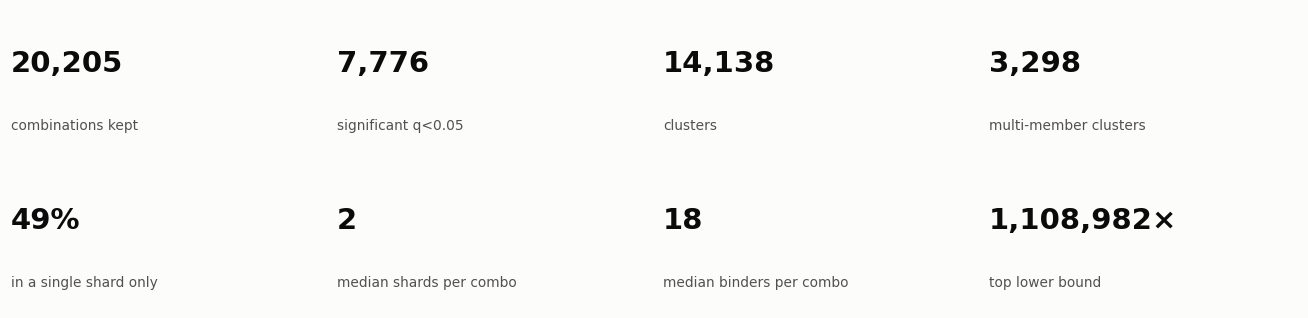

In [28]:
sig = combos[combos.q_value_mh < 0.05]
fig = stat_tiles([
    ("combinations kept", f"{len(combos):,}"),
    ("significant q<0.05", f"{len(sig):,}"),
    ("clusters", f"{len(clusters):,}"),
    ("multi-member clusters", f"{int((clusters.n_members > 1).sum()):,}"),
    ("in a single shard only", f"{(combos.n_strata == 1).mean():.0%}"),
    ("median shards per combo", f"{combos.n_strata.median():.0f}"),
    ("median binders per combo", f"{combos.n_binder.median():.0f}"),
    ("top lower bound", f"{combos.enrichment_mh_lo95.max():,.0f}\u00d7"),
])
plt.show()

## Pooled vs. stratified — how much the sub-library correction matters

Each point is one combination. The diagonal is "the correction changed nothing".
Distance from it is how much of the pooled score was really the shard it sat in.

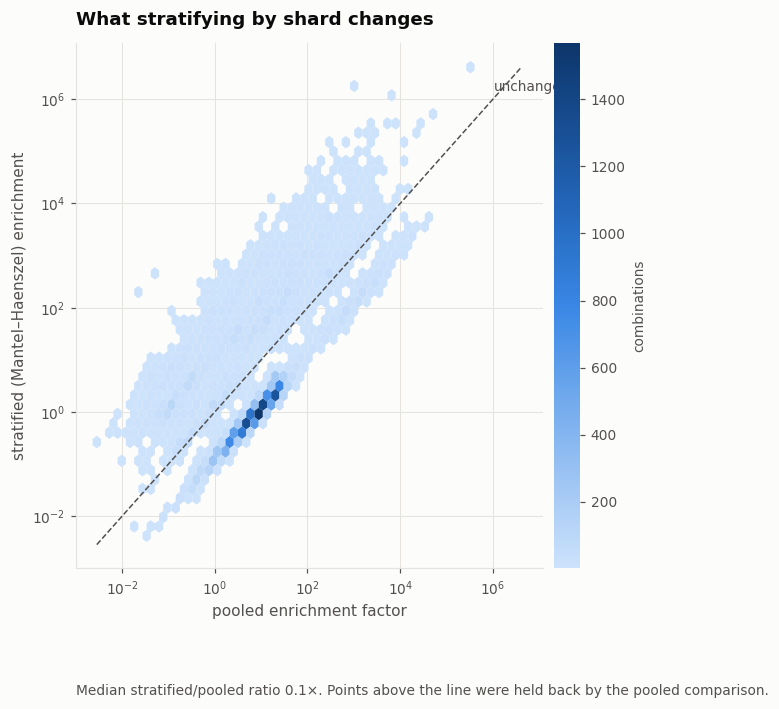

In [29]:
m = combos[np.isfinite(combos.enrichment_factor) & np.isfinite(combos.enrichment_mh)
           & (combos.enrichment_factor > 0) & (combos.enrichment_mh > 0)]
fig, ax = plt.subplots(figsize=(6.6, 6.2))
hb = ax.hexbin(m.enrichment_factor, m.enrichment_mh, xscale="log", yscale="log",
               gridsize=45, cmap=SEQUENTIAL, mincnt=1, linewidths=0)
cb = fig.colorbar(hb, ax=ax, pad=0.02); cb.set_label("combinations", color=INK_SOFT, fontsize=9)
cb.outline.set_visible(False)
lim = [min(m.enrichment_factor.min(), m.enrichment_mh.min()),
       max(m.enrichment_factor.max(), m.enrichment_mh.max())]
ax.plot(lim, lim, color=INK_SOFT, lw=1, ls="--")
ax.annotate("unchanged", xy=(lim[1]*0.25, lim[1]*0.35), color=INK_SOFT, fontsize=9)
ax.set_xlabel("pooled enrichment factor")
ax.set_ylabel("stratified (Mantel\u2013Haenszel) enrichment")
ax.set_title("What stratifying by shard changes")
strip_spines(ax)
ratio = (m.enrichment_mh / m.enrichment_factor)
caption(ax, f"Median stratified/pooled ratio {ratio.median():,.1f}\u00d7. "
            "Points above the line were held back by the pooled comparison.")
plt.show()

## How many shards does a combination live in?

A combination confined to one shard is only ever compared against that shard's
compounds, so its estimate rests on a narrow slice of the library.

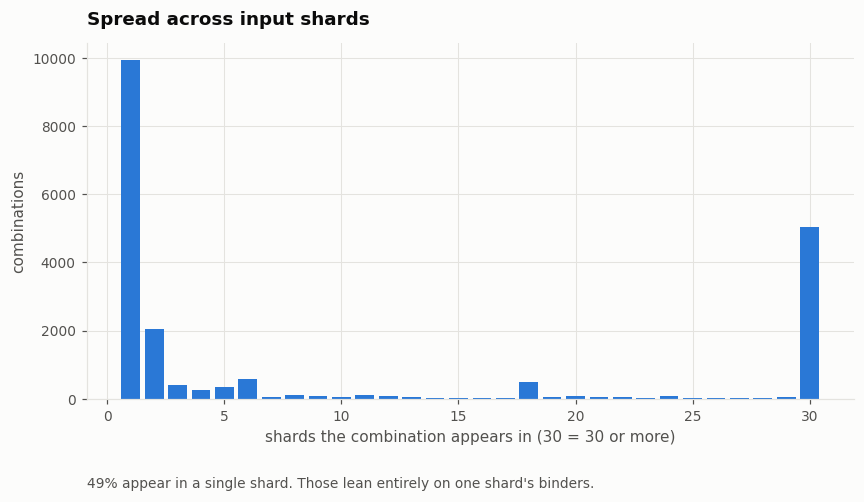

In [30]:
vc = combos.n_strata.clip(upper=30).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(vc.index, vc.values, color=SERIES[0], width=0.8, linewidth=0)
ax.set_xlabel("shards the combination appears in (30 = 30 or more)")
ax.set_ylabel("combinations")
ax.set_title("Spread across input shards")
strip_spines(ax)
caption(ax, f"{(combos.n_strata == 1).mean():.0%} appear in a single shard. "
            "Those lean entirely on one shard's binders.")
plt.show()

## Distribution of enrichment

Both estimates on one axis, so the shift between them is visible directly.

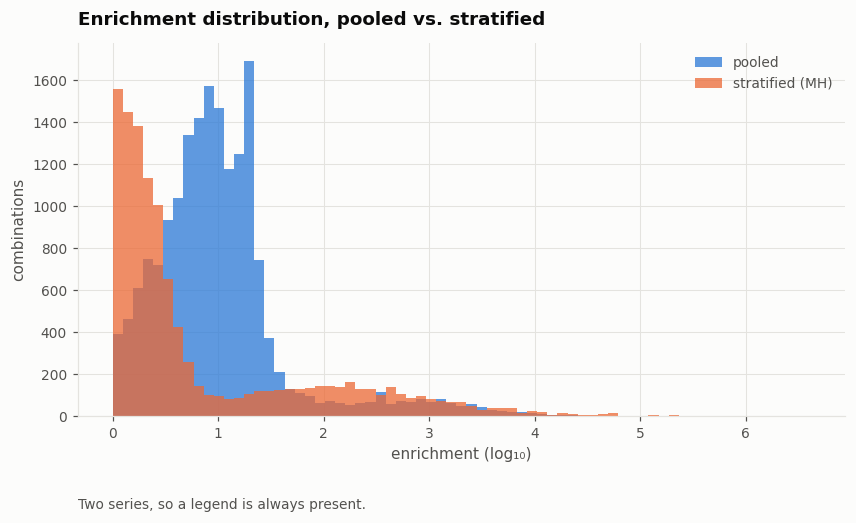

In [31]:
fig, ax = plt.subplots(figsize=(9, 4.4))
bins = np.linspace(0, np.log10(max(finite(m.enrichment_mh).max(),
                                   finite(m.enrichment_factor).max())), 70)
ax.hist(np.log10(finite(m.enrichment_factor)), bins=bins, color=SERIES[0],
        alpha=0.75, label="pooled", linewidth=0)
ax.hist(np.log10(finite(m.enrichment_mh)), bins=bins, color=SERIES[1],
        alpha=0.75, label="stratified (MH)", linewidth=0)
ax.set_xlabel("enrichment (log\u2081\u2080)")
ax.set_ylabel("combinations")
ax.set_title("Enrichment distribution, pooled vs. stratified")
ax.legend(loc="upper right")
strip_spines(ax)
caption(ax, "Two series, so a legend is always present.")
plt.show()

## Top combinations

Ranked on the stratified lower bound. `frag_smiles` shows the two members as
separate fragments with open attachment points; the rendered, bonded form is in
`top_combinations_smiles_size2.csv` and drawn below.

In [32]:
cols = ["combo_key", "n_binder", "n_nonbinder", "n_strata", "binder_per_nonbinder",
        "enrichment_factor", "enrichment_mh", "enrichment_mh_lo95", "q_value_mh", "frag_smiles"]
top = combos.sort_values("binder_per_nonbinder", ascending=False).head(25)
top[cols].reset_index(drop=True)

,combo_key,n_binder,n_nonbinder,n_strata,binder_per_nonbinder,enrichment_factor,enrichment_mh,enrichment_mh_lo95,q_value_mh,frag_smiles
0,F018169|F002369,397,0,57,39700.000000,inf,inf,370.091999,0.0,[6*]C(=O)Nc1ncc(C2CC2)s1.[5*]N1Cc2cc([14*])nn2CC1C
1,F000118|F018169,164,0,54,16400.000000,inf,inf,147.114313,0.0,[3*]Oc1ccc([16*])cc1.[6*]C(=O)Nc1ncc(C2CC2)s1
2,F137303|F000138,35,0,22,3500.000000,inf,inf,27.683423,0.0,[9*]n1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1=O.[8*]CCC(=O)NC[8*]
3,F000220|F221715,35,0,23,3500.000000,inf,inf,27.683408,0.0,[3*]OCC(=O)NC[8*].[14*]c1cncc(C#Cc2cc3n(n2)CCCC3)n1
4,F003497|F054084,10,0,8,1000.000000,inf,inf,6.363795,0.0,[5*]Nc1cc(C2CCC2)[nH]n1.[8*]CCN(C)c1nc([14*])nc(N[C@@H](...
5,F003427|F054084,10,0,8,1000.000000,inf,inf,6.363795,0.0,[5*]Nc1cc(CC2CC2)[nH]n1.[8*]CCN(C)c1nc([14*])nc(N[C@@H](...
6,F031113|F024684,10,0,9,1000.000000,inf,inf,6.450558,0.0,[8*]CN1Cc2cc([14*])nn2CC1C.[6*]C(=O)Nc1ncc(C)s1
7,F031113|F018169,10,0,9,1000.000000,inf,inf,6.450558,0.0,[8*]CN1Cc2cc([14*])nn2CC1C.[6*]C(=O)Nc1ncc(C2CC2)s1
8,F000118|F024684,163,1,54,161.386139,3.270014e+05,4.103978e+06,543701.962856,0.0,[3*]Oc1ccc([16*])cc1.[6*]C(=O)Nc1ncc(C)s1
9,F000118|F012233,158,6,54,26.289517,5.282845e+04,5.897923e+05,259859.865690,0.0,[3*]Oc1ccc([16*])cc1.[6*]C(=O)Nc1ncc(CCOC)s1


the two fragments joined at the bond that connected them:


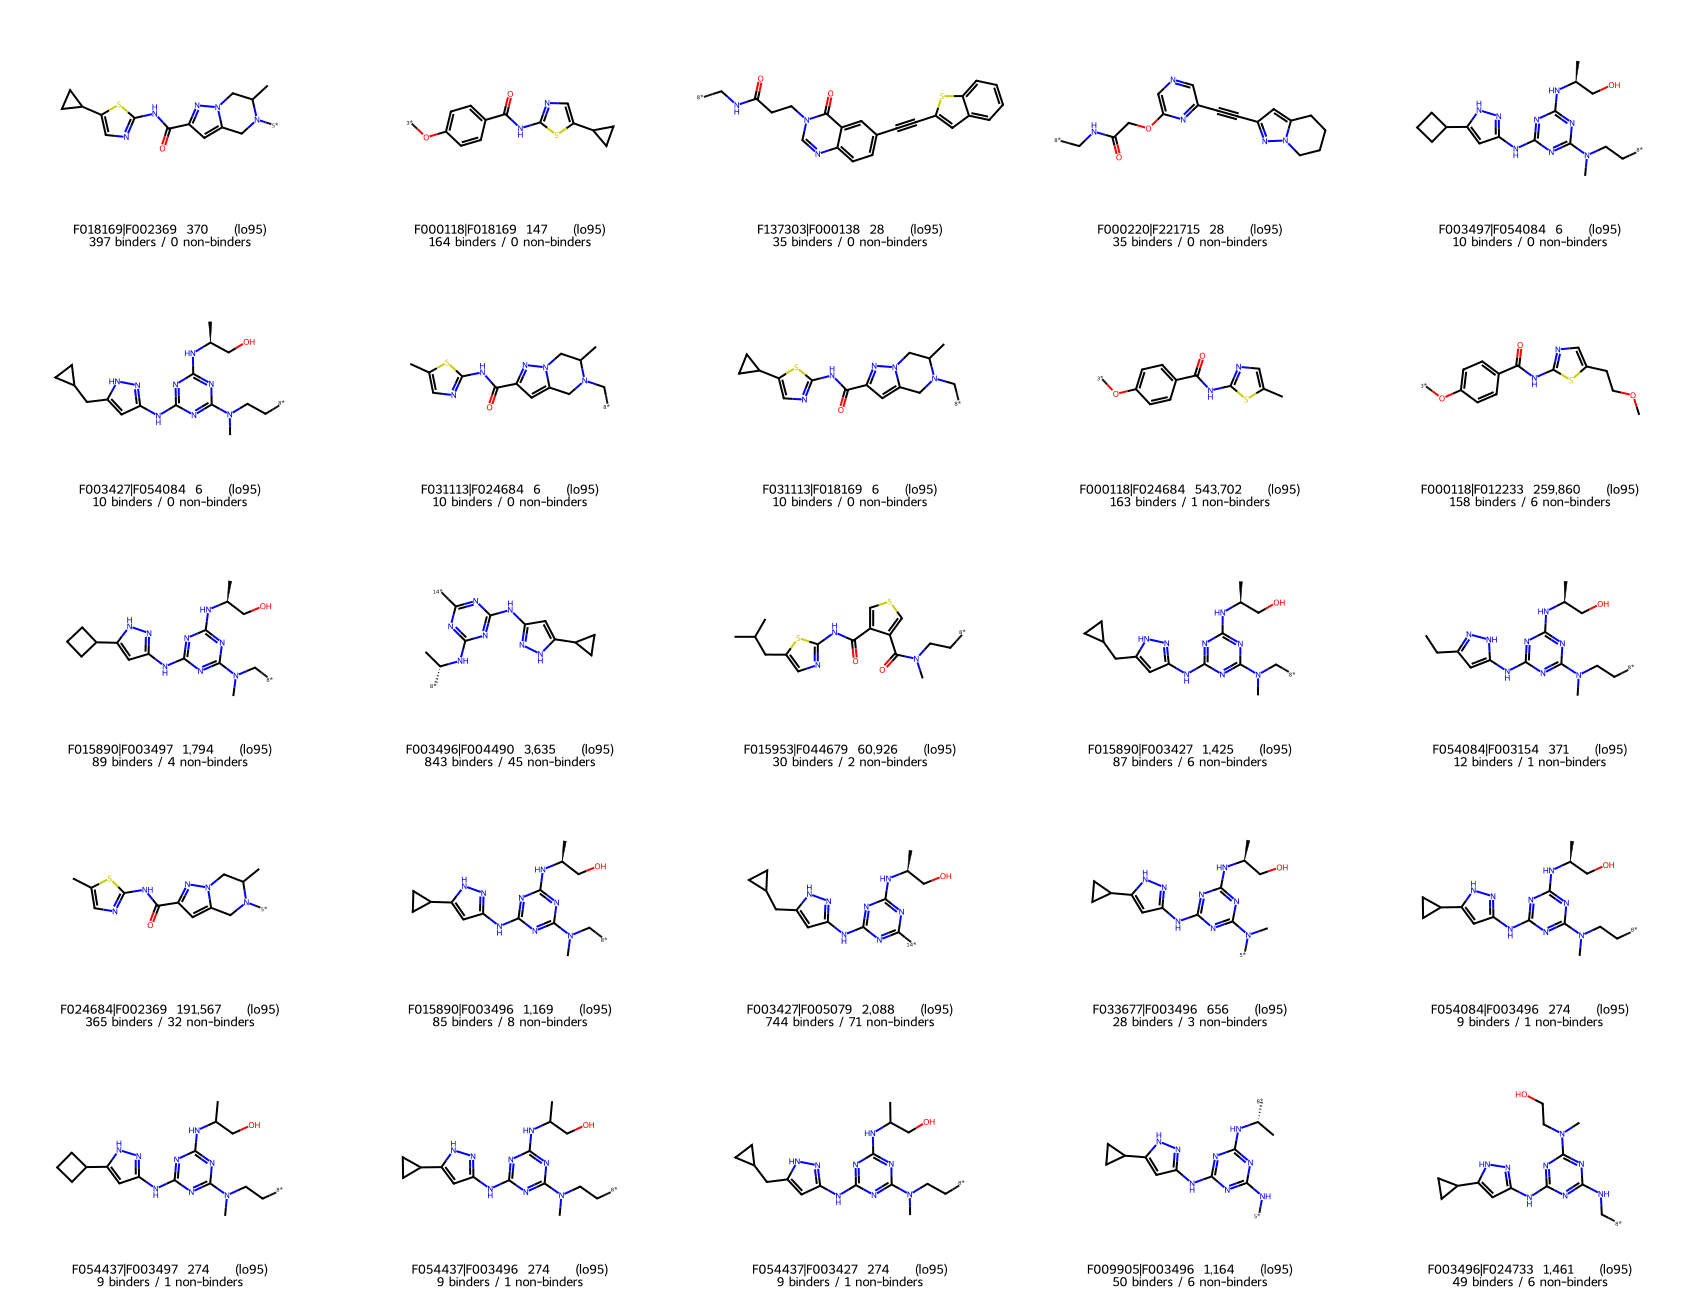

In [33]:
from rdkit import Chem, RDLogger
from rdkit.Chem import Draw
RDLogger.DisableLog("rdApp.*")

rendered = pd.read_csv(RESULTS / f"top_combinations_smiles_size{SIZE}.csv")
mols, legends = [], []
for _, r in rendered.head(25).iterrows():
    if not isinstance(r.combination_smiles, str):
        continue
    mol = Chem.MolFromSmiles(r.combination_smiles)
    if mol is None:
        continue
    mols.append(mol)
    legends.append(f"{r.combo_key}  {r.enrichment_mh_lo95:,.0f}\u00d7 (lo95)\n"
                   f"{int(r.n_binder):,} binders / {int(r.n_nonbinder):,} non-binders")
print("the two fragments joined at the bond that connected them:")
draw_grid(mols, legends, mols_per_row=5, sub_img_size=(340, 260))

---

# Clustered combinations

Combinations whose fragments share a scaffold key after terminal methyls and
halogens are stripped — so a chloro and a methyl variant of the same pair pool
their compounds instead of splitting them.

`n_members` is how many combinations went into the cluster. `pooling_gain` is the
cluster's lower bound over its best single member's; treat it as a description,
not a verdict, since the best member is picked after seeing the data and so its
score is inflated by selection.

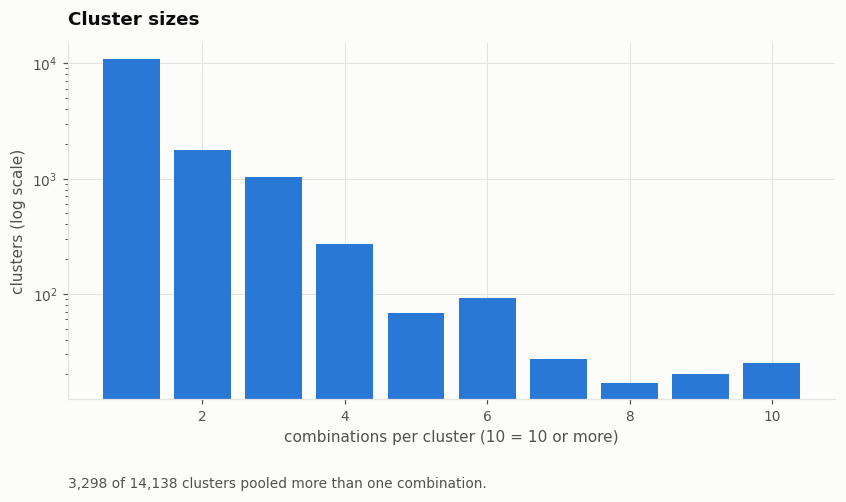

In [34]:
multi = clusters[clusters.n_members > 1]
vc = clusters.n_members.clip(upper=10).value_counts().sort_index()
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(vc.index, vc.values, color=SERIES[0], width=0.8, linewidth=0)
ax.set_yscale("log")
ax.set_xlabel("combinations per cluster (10 = 10 or more)")
ax.set_ylabel("clusters (log scale)")
ax.set_title("Cluster sizes")
strip_spines(ax)
caption(ax, f"{len(multi):,} of {len(clusters):,} clusters pooled more than one combination.")
plt.show()

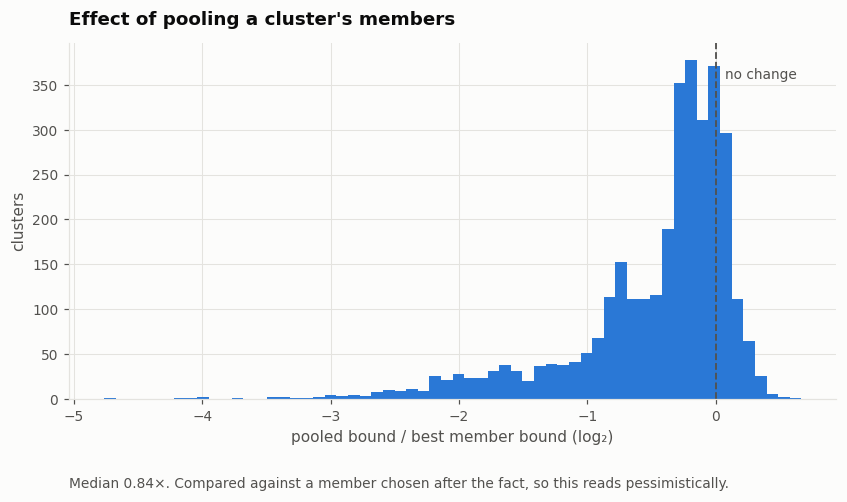

In [35]:
g = multi["pooling_gain"].replace([np.inf, -np.inf], np.nan).dropna()
g = g[g > 0]
fig, ax = plt.subplots(figsize=(9, 4.2))
ax.hist(np.log2(g), bins=60, color=SERIES[0], linewidth=0)
ax.axvline(0, color=INK_SOFT, lw=1.2, ls="--")
ax.annotate("no change", xy=(0, ax.get_ylim()[1]*0.9), xytext=(6, 0),
            textcoords="offset points", color=INK_SOFT, fontsize=9)
ax.set_xlabel("pooled bound / best member bound (log\u2082)")
ax.set_ylabel("clusters")
ax.set_title("Effect of pooling a cluster's members")
strip_spines(ax)
caption(ax, f"Median {g.median():.2f}\u00d7. Compared against a member chosen after the "
            "fact, so this reads pessimistically.")
plt.show()

## Top clusters

In [40]:
ccols = ["cluster_key", "n_members", "n_binder", "n_nonbinder", "n_strata",
         "binder_per_nonbinder", "enrichment_factor", "enrichment_mh",
         "enrichment_mh_lo95", "q_value_mh", "best_member", "pooling_gain"]
top_clusters = clusters.sort_values("binder_per_nonbinder", ascending=False).head(25)
top_clusters[ccols].reset_index(drop=True)

,cluster_key,n_members,n_binder,n_nonbinder,n_strata,binder_per_nonbinder,enrichment_factor,enrichment_mh,enrichment_mh_lo95,q_value_mh,best_member,pooling_gain
0,*CCC(=O)NC*|*n1cnc2ccc(C#Cc3cc4ccccc4s3)cc2c1=O,1,35,0,22,inf,inf,inf,27.683423,0.0,F137303|F000138,1.000000
1,*CNC(=O)CO*|*c1cncc(C#Cc2cc3n(n2)CCCC3)n1,1,35,0,23,inf,inf,inf,27.683408,0.0,F000220|F221715,1.000000
2,*C(=O)Nc1ncc(C2CC2)s1|*Oc1ccc(*)cc1,1,164,0,54,inf,inf,inf,147.114313,0.0,F000118|F018169,1.000000
3,*CCNc1nc(*)nc(N[C@@H](C)CO)n1|*Nc1cc(C2CCC2)[nH]n1,1,10,0,8,inf,inf,inf,6.363795,0.0,F003497|F054084,1.000000
4,*CCNc1nc(*)nc(N[C@@H](C)CO)n1|*Nc1cc(CC2CC2)[nH]n1,1,10,0,8,inf,inf,inf,6.363795,0.0,F003427|F054084,1.000000
5,*C(=O)Nc1ncc(C2CC2)s1|*CN1CCn2nc(*)cc2C1,1,10,0,9,inf,inf,inf,6.450558,0.0,F031113|F018169,1.000000
6,*C(=O)Nc1nccs1|*CN1CCn2nc(*)cc2C1,1,10,0,9,inf,inf,inf,6.450558,0.0,F031113|F024684,1.000000
7,*C(=O)Nc1ncc(C2CC2)s1|*c1cc2n(n1)CCN(*)C2,1,397,0,57,inf,inf,inf,370.091999,0.0,F018169|F002369,1.000000
8,*C(=O)Nc1nccs1|*Oc1ccc(*)cc1,1,163,1,54,163.000000,3.270014e+05,4.103978e+06,543701.962856,0.0,F000118|F024684,1.000000
9,*C(=O)Nc1ncc(CCO)s1|*Oc1ccc(*)cc1,1,158,6,54,26.333333,5.282845e+04,5.897923e+05,259859.865690,0.0,F000118|F012233,1.000000


### A pooled cluster, member by member

The members of the best multi-member cluster, with the scaffold key they share.

In [41]:
best = multi.sort_values("binder_per_nonbinder", ascending=False).iloc[0]
names = str(best["members"]).split(";")
member_rows = combos[combos.combo_key.isin(names)].sort_values("enrichment_mh_lo95", ascending=False)
print(f"cluster key: {best.cluster_key}")
print(f"{int(best.n_members)} members, pooled to {int(best.n_binder):,} binders "
      f"/ {int(best.n_nonbinder):,} non-binders, lo95 {best.enrichment_mh_lo95:,.0f}\u00d7\n")
member_rows[["combo_key", "n_binder", "n_nonbinder", "enrichment_mh",
             "enrichment_mh_lo95", "frag_smiles"]].reset_index(drop=True)

cluster key: *CNc1nc(*)nc(N[C@@H](C)CO)n1|*Nc1cc(C2CCC2)[nH]n1
2 members, pooled to 104 binders / 7 non-binders, lo95 1,578×



,combo_key,n_binder,n_nonbinder,enrichment_mh,enrichment_mh_lo95,frag_smiles
0,F015890|F003497,89,4,5072.550802,1793.615820,[8*]CN(C)c1nc([14*])nc(N[C@@H](C)CO)n1.[5*]Nc1cc(C2CCC2)...
1,F003497|F016511,15,3,1226.282223,348.463088,[5*]Nc1cc(C2CCC2)[nH]n1.[8*]CNc1nc([14*])nc(N[C@@H](C)CO)n1


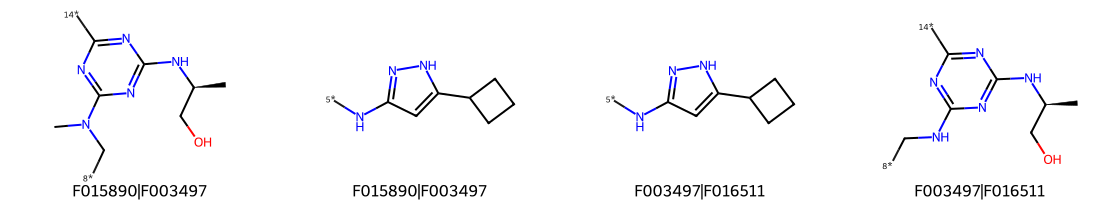

In [42]:
mols, legends = [], []
for _, r in member_rows.head(8).iterrows():
    for part in str(r.frag_smiles).split("."):
        mol = Chem.MolFromSmiles(part)
        if mol is not None:
            mols.append(mol)
            legends.append(f"{r.combo_key}")
draw_grid(mols, legends, mols_per_row=4, sub_img_size=(280, 210))

## Export

In [39]:
out = Path("../reports"); out.mkdir(exist_ok=True)
combos.sort_values("enrichment_mh_lo95", ascending=False)[cols].head(1000) \
    .to_csv(out / f"top_combinations_size{SIZE}.csv", index=False)
clusters.sort_values("enrichment_mh_lo95", ascending=False)[ccols].head(1000) \
    .to_csv(out / f"top_clusters_size{SIZE}.csv", index=False)
print("wrote", out.resolve())

wrote /home/aserrano/frags-DEL/BRICS_fragmentation/reports
